In [ ]:
#implementacion de perceptron multicapa con backpropagation
import torch
import numpy as np
from graphviz import Digraph

In [36]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def show_graph(root, format='svg', rankdir='LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges= trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(name=str(id(n)), label="{%s | data %.4f | grad %.4f }" % (n.name, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

import os
os.environ['PATH'] += r';C:\Program Files\Graphviz\bin'

class Value():
    def __init__(self, data, _children=(), _op='', name=''):
        self.data = data
        self.name = name
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None #funcion que se va a llamar para propagar el gradiente hacia atras

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
    
        def _backward(): #cuando se llama a backward en el nodo de salida, se va a llamar a esta funcion para propagar el gradiente hacia atras
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __pow__(self, other): #funcion para elevar a una potencia, solo soporta int/float por ahora
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += out.grad * other * (self.data ** (other - 1))
        out._backward = _backward
        return out
    
    def exp(self): #funcion exponencial
        out = np.exp(self.data)
        out = Value(out, _children=(self,), _op='exp')
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    
    def tanh(self): #funcion tangente hiperbólica
        x = self.data
        t = (np.e ** (2*x) - 1) / (np.e ** (2*x) + 1)
        out = Value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def backward(self): #funcion para propagar el gradiente hacia atras, se llama en el nodo de salida
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad}, _op="{self._op}", name="{self.name}")'

In [37]:
#perceptron/neurona, no tiene funcion de activacion, no tiene bias
W0 = Value(-.5, name='W0') #pesos
x0 = Value(.5, name='x0')
W1 = Value(-.3, name='W1')
x1 = Value(2, name='x1')
W0x0 = W0 * x0; W0x0.name = 'W0x0'
W1x1 = W1 * x1; W1x1.name = 'W1x1'
yhat = W0x0 + W1x1; yhat.name = 'yhat' #valor predicho de la funcion
yhat = yhat.tanh(); yhat.name = 'tanh(yhat)'
y = Value(.8, name='y') # valor esperado
L = y - yhat; L.name = 'L' #fucion de perdida, diferencia entre el valor real y el predicho
L.backward()
W0.grad

-0.26121149393241616

In [38]:
 #value representa solo un valor, un tensor representa un array de valores, en este caso un array de un solo valor
W0 = torch.tensor(-.5); W0.requires_grad = True #calcula el gradiente de este tensor, es decir, la derivada de la funcion de perdida con respecto a este tensor
x0 = torch.tensor(.5); x0.requires_grad = True
W1 = torch.tensor(-.3); W1.requires_grad = True
x1 = torch.tensor(2.); x1.requires_grad = True
yhat = torch.tanh(W0 * x0 + W1 * x1); #esto calcula el valor predicho de la funcion, en este caso la tangente hiperbólica de la suma ponderada de las entradas
y = torch.tensor(.8); y.requires_grad = True # valor esperado
L = y - yhat #fucion de perdida, diferencia entre el valor real y el predicho
L.backward() #esto calcula el gradiente de L con respecto a W0, W1, x0 y x1
W0.grad

tensor(-0.2612)

In [60]:
class Neuron:
    def __init__(self, nin):
        self.W = [Value(np.random.uniform(-1, 1)) for _ in range(nin)] #pesos, un array de valores aleatorios entre -1 y 1, cada peso corresponde a una entrada de la neurona, el numero de pesos es igual al numero de entradas
        self.b = Value(np.random.uniform(-1, 1)) #bias, un valor que se suma a la salida de la neurona, esto permite que la neurona pueda aprender a activar incluso cuando todas las entradas son cero, puede ser opcional
    def __repr__(self):
        return f"Neuron(nin={len(self.W)})"
    def __call__(self, x): #esto hace que la neurona sea callable, es decir, que se pueda llamar como una funcion, esto es lo que se llama forward pass, es decir, calcular la salida de la neurona dada una entrada
        return sum([wi * xi for wi, xi in zip(self.W, x)], self.b) # esto calcula la salida de la neurona, es decir, la suma ponderada de las entradas mas el bias, esto es lo que se llama la funcion de activacion lineal, luego se puede aplicar una funcion de activacion no lineal como tanh o relu para obtener la salida final de la neurona
class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] #esto crea una capa de neuronas, es decir, un array de neuronas, cada neurona tiene un numero de entradas igual a nin, el numero de neuronas es igual a nout
    
    def __call__(self, x):
        act = [n(x) for n in self.neurons] #la capa de neuronas puede tener una funcion de activacion, en este caso se va a usar la funcion de activacion lineal, es decir, la salida de la capa es la suma de las salidas de las neuronas, la otra opcion es que cada neurona tenga su propia funcion de activacion, en el caso de querer permitir que el usuario elija la funcion de activacion.
        return act
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP: #Multi Layer Perceptron, una red neuronal con varias capas de neuronas, cada capa tiene un numero de neuronas, cada neurona tiene un numero de entradas, cada entrada tiene un peso, cada neurona tiene una funcion de activacion, la salida de una capa es la entrada de la siguiente capa
    
    def __init__ (self, nin, nouts):
        self.nin = nin
        self.nouts = nouts
        sz = [nin] + nouts
        #self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #esto crea una red neuronal con varias capas, cada capa tiene un numero de neuronas igual a nouts[i], el numero de entradas de la primera capa es igual a nin, el numero de entradas de las siguientes capas es igual al numero de neuronas de la capa anterior
        self.layers = [Layer(a, b) for a, b in zip(sz, sz[1:])] #esto hace lo mismo que la linea anterior pero de una forma mas elegante, zip hace que se itere sobre dos listas al mismo tiempo, en este caso se itera sobre la lista de tamaños de entradas y la lista de tamaños de salidas, esto es lo que se llama un perceptron multicapa
    
    def __call__(self, x):
        for l in self.layers:
            x = l(x)
        return x
    
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

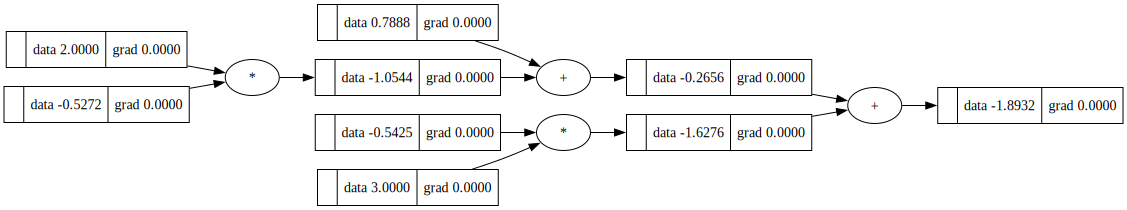

In [42]:
x = [2, 3]
n = Neuron(2)
show_graph(n(x))

In [61]:
model = MLP(2, [3, 3, 1]) #perceptron de 2 entradas, 3 capas ocultas con 3 neuronas cada una, y una capa de salida con 1 neurona
model

MLP of [Layer of [Neuron(nin=2), Neuron(nin=2), Neuron(nin=2)], Layer of [Neuron(nin=3), Neuron(nin=3), Neuron(nin=3)], Layer of [Neuron(nin=3)]]

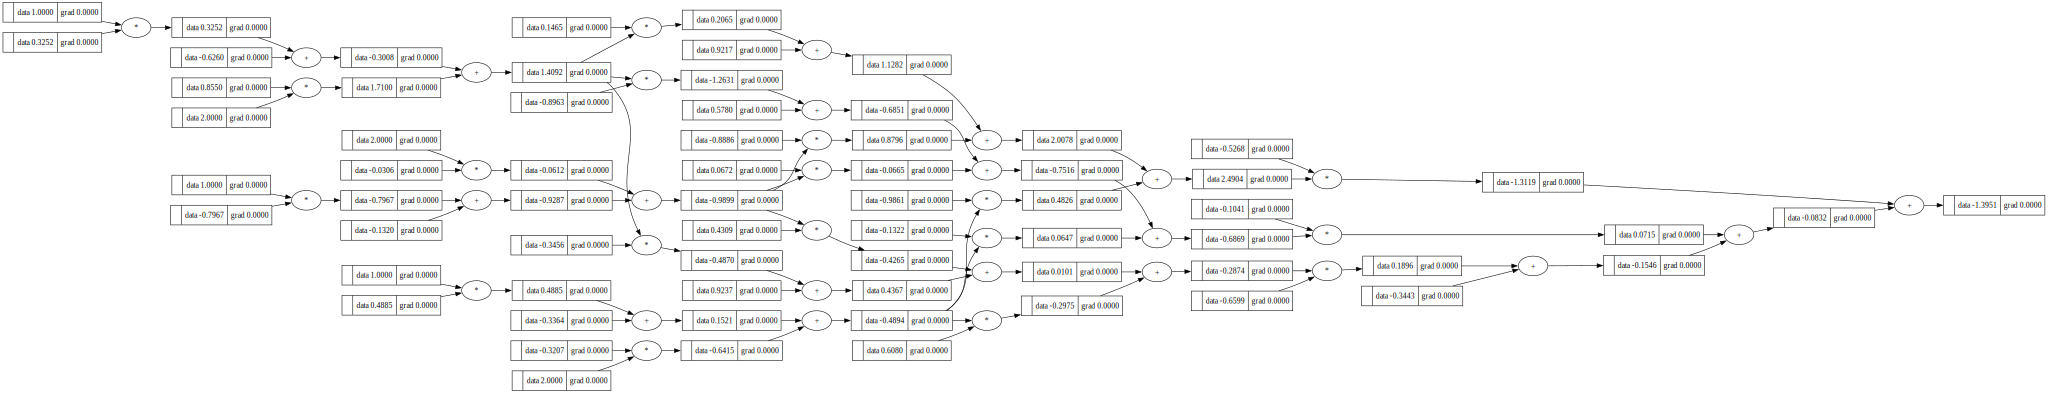

In [62]:
show_graph(model([1, 2])[0]) #esto calcula la salida de la red neuronal dada una entrada, en este caso la entrada es un array de 2 valores, el resultado es un array de 1 valor, que es la salida de la red neuronal, esto es lo que se llama el forward pass, es decir, calcular la salida de la red neuronal dada una entrada